In [63]:
pip install groq gTTS matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\Riya Malhotra\Desktop\g\.venv\Scripts\python.exe: No module named pip


In [64]:
import os
import base64
import json
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
import groq
from langchain.agents import create_agent
from langchain.tools import tool
from gtts import gTTS
import matplotlib.pyplot as plt

In [65]:
from dotenv import load_dotenv
load_dotenv()

True

In [66]:
with open("blood_report.png","rb") as f:
    image_encoded=base64.b64encode(f.read()).decode()

In [67]:
print(image_encoded)

...


In [68]:
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [69]:
from langchain_core.messages import HumanMessage
human_message=HumanMessage(content=[
    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_encoded}"}},
    {"type": "text",      "text": "Extract all test results. For each: test name, value, normal range, and whether it is NORMAL/HIGH/LOW."},
])

In [70]:
response=llm.invoke([human_message])

In [71]:
response.formatted=response.content

In [72]:
text_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [73]:
summary_prompt=f"Summerize this given blood report in a simpler language so that a normal human being can understand it:{response.formatted}"
summary_report=text_llm.invoke(summary_prompt).content

In [74]:
print(summary_report)

Okay, let's break down your blood report in simple terms:

---

**Your Blood Report: A Simple Summary**

Good news first! Many parts of your blood report look healthy. However, there's one important area that needs attention: your cholesterol and other fats.

Here's a breakdown:

**1. Your General Blood Health (Red Blood Cells, White Blood Cells, Platelets):**
*   **Hemoglobin & Hematocrit (Oxygen-carrying cells):** These are **NORMAL**. This means your red blood cells, which carry oxygen throughout your body, are at a healthy level.
*   **WBC (White Blood Cells - Your Immune System):** This is **NORMAL**. Your body's infection-fighting cells are at a good level, suggesting your immune system is working well.
*   **Platelets (Blood Clotting Cells):** These are **NORMAL**. Your cells that help your blood clot when you get a cut are at a healthy level.
    *   **Overall for this section: Everything looks good here!**

**2. Your Blood Sugar Levels:**
*   **Glucose (Fasting Blood Sugar):**

In [75]:
tts=gTTS(text=summary_report,lang="en")
tts.save("report.mp3")

In [79]:
from IPython.display import Audio

In [81]:
Audio("report.mp3")

In [82]:
blood_data = {
    "Hemoglobin":        {"value": 15.1, "low": 13.5, "high": 17.5},
    "Total Cholesterol": {"value": 238,  "low": 0,    "high": 200},
    "LDL Cholesterol":   {"value": 162,  "low": 0,    "high": 100},
    "HDL Cholesterol":   {"value": 36,   "low": 40,   "high": 100},
    "Triglycerides":     {"value": 188,  "low": 0,    "high": 150},
    "Glucose":           {"value": 92,   "low": 70,   "high": 99},
    "HbA1c":             {"value": 5.3,  "low": 0,    "high": 5.7},
    "Creatinine":        {"value": 1.0,  "low": 0.7,  "high": 1.3},
}

In [83]:
tests=list(blood_data.keys())

In [84]:
tests

['Hemoglobin',
 'Total Cholesterol',
 'LDL Cholesterol',
 'HDL Cholesterol',
 'Triglycerides',
 'Glucose',
 'HbA1c',
 'Creatinine']

In [86]:
values=[d["value"] for d in blood_data.values()]

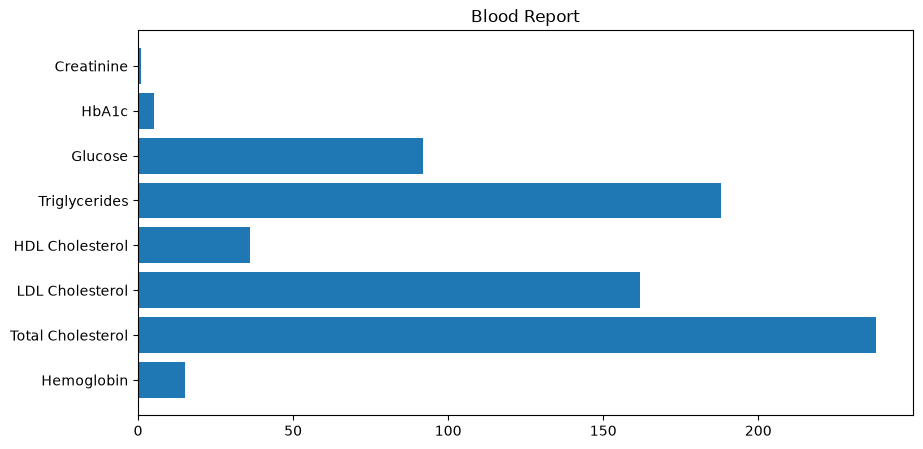

In [99]:
plt.figure(figsize=(10,5))
plt.barh(tests,values)
plt.title("Blood Report")
plt.savefig("chart.png")
plt.show()

In [101]:
question="What should i do to handle high cholestrol?"
gTTS(text=question,lang="en").save("question.mp3")

In [102]:
Audio("question.mp3")

In [105]:
from groq import Groq
client=Groq()

In [108]:
with open("question.mp3","rb") as f:
    transcribe=client.audio.transcriptions.create(
        file=("question.mp3",f.read()),
        model="whisper-large-v3"
    )